<h1 style="text-align: center;">Deep Learning Project</h1>

** **

## <p style="text-align: center;"><i>02 - Pre-Processing </i></p>

** **
<p style="text-align: center;">
David Cascão - 20240851 <br>
Jan-Louis Schneider - 20240506 <br>
Emir Kamiloglu - 20240945 <br>
Marta Boavida - 20240519 <br>
Sofia Gomes - 20240848
</p>


## <span style="color:#FF007F"> Notebook </span> 

In this notebook, we explore and prepare a dataset of animal images for deep learning tasks.  
We follow a structured pipeline to clean the data, relabel using CLIP, remove backgrounds, balance classes, and visualize results.  
Each step builds on the previous one, ensuring a robust and model-friendly dataset.


## <span style="color:#FF007F">Table of Contents</span>

<a class="anchor" id="top"></a>

1. [Package Installations](#one-bullet) <br>

2. [Import Libraries](#two-bullet) <br>

3. [Dataframe Structure & Config](#three-bullet) <br>

4. [CLIP-Based Relabeling](#four-bullet) <br>

5. [Background Removal](#five-bullet) <br>

6. [Data Augmentation & Balancing](#six-bullet) <br>

7. [Class Distribution Through Preprocessing](#seven-bullet) <br>


<a class="anchor" id="one-bullet"></a>

## <span style="color:#FF007F"> 1. Package Installations </span>  

<a href="#top">Top &#129033;</a>

We begin by installing the necessary libraries and pretrained models required throughout the notebook.


In [1]:
%pip install torch clip matplotlib pandas tqdm Pillow
%pip install ftfy regex tqdm
%pip install git+https://github.com/openai/CLIP.git
%pip install rembg[gpu] pillow matplotlib torch torchvision pandas numpy opencv-python
%pip install albumentations

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/openai/CLIP.git to c:\users\asus.laptop-sfdpa4g4\appdata\local\temp\pip-req-build-4ne7128i
  Resolved https://github.com/openai/CLIP.git to commit dcba3cb2e2827b402d2701e7e1c7d9fed8a20ef1
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\ASUS.LAPTOP-SFDPA4G4\AppData\Local\Temp\pip-req-build-4ne7128i'



Note: you may need to restart the kernel to use updated packages.


<a class="anchor" id="two-bullet"></a>

## <span style="color:#FF007F"> 2. Import Libraries </span>  

<a href="#top">Top &#129033;</a>

Here we import all essential libraries, including utilities for image processing, machine learning, and visualization.


In [1]:
import torch
import clip
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw, ImageFont
import gc
from tqdm import tqdm
import numpy as np
import PIL.Image
from pathlib import Path
PIL.Image.MAX_IMAGE_PIXELS = 115600000 * 2 
import cv2
from rembg import remove
import rembg
import albumentations as A
import random

c:\Users\ASUS.LAPTOP-SFDPA4G4\anaconda3\envs\Data Mining\lib\site-packages\albumentations\__init__.py:13: UserWarning: A new version of Albumentations is available: 2.0.5 (you have 1.4.18). Upgrade using: pip install -U albumentations. To disable automatic update checks, set the environment variable NO_ALBUMENTATIONS_UPDATE to 1.
  check_for_updates()


<a class="anchor" id="three-bullet"></a>

## <span style="color:#FF007F">3. Dataframe Structure & Config</span>  

<a href="#top">Top &#129033;</a>

This section sets up the dataset structure, defines preprocessing logic, and establishes key configurations.  
It also includes helper functions to visualize class distributions.


In [21]:

def create_preproc_dataframe(input_df):
    """Create initial preprocessing dataframe structure
    
    Args:
        train_df: Input DataFrame with raw data information
        
    Returns:
        DataFrame with preprocessing structure and initial values
    """
    return pd.DataFrame({
        'original_class': input_df['phylum']+"_"+input_df['family'],
        'original_path': Config.DATA_ROOT / input_df['file_path'],
        'clip_class': None,
        'clip_top3_match_probs': [{}]*len(input_df),
        'clip_status': 0,
        'bg_status': 0,
        'bg_path': None,
        'aug_transforms': None,
        'aug_paths': None
    }).astype({
        'clip_top3_match_probs': 'object',
        'aug_transforms': 'object',
        'aug_paths': 'object'
    })

def plot_class_evolution(df):
    """Plot class distribution evolution with consistent y-axis scale."""
    fig, axes = plt.subplots(1, 4, figsize=(20, 5), sharey=True)
    
    # Calculate all counts first to determine global ylim
    counts = [
        df['original_class'].value_counts().sort_index(),
        df['clip_class'].value_counts().sort_index(),
        df.groupby('clip_class')['bg_status'].apply(lambda x: len(x) + x.sum()).sort_index(),
        df.groupby('clip_class').apply(
            lambda x: len(x) + x['bg_status'].sum() + x['aug_paths'].apply(
                lambda p: len(p) if p is not None else 0).sum()).sort_index()
    ]

    global_max = max(c.max() for c in counts)

    titles = ['Original', 'After CLIP', 'After BG Removal', 'After Augmentation']
    for ax, title, count in zip(axes, titles, counts):
        ax.bar(range(len(count)), count.values, width=0.8, color='0.7')
        ax.set_title(f"Class Distribution - {title}", fontsize=10)
        ax.set_ylim(0, global_max * 1.05)  # 5% padding
        ax.set_xticks([])
        ax.tick_params(axis='y', labelsize=8)
    
    plt.tight_layout()
    plt.show()

# Configuration
class Config:
    # Paths
    DATA_ROOT = Path("../data")
    SAVE_DIR = Path("../preprocessed")
    PREPROC_ROOT = Path("../data_preprocessed")
    # Processing directories
    CLIP_GRIDS = SAVE_DIR / "clip_grids"
    BG_GRIDS = SAVE_DIR / "bg_grids"
    AUG_GRIDS = SAVE_DIR / "aug_grids"
    
    # CLIP parameters
    CLIP_THRESHOLD = 0.5
    TILE_SIZE = (224,224)  # Size of each tile for CLIP processing
    GRID_SIZE = (8, 8)  # rows, columns
    FONT_SIZE = 8
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    
    @classmethod
    def setup_dirs(cls):
        """Create all required directories"""
        cls.CLIP_GRIDS.mkdir(parents=True, exist_ok=True)
        cls.BG_GRIDS.mkdir(parents=True, exist_ok=True)
        cls.AUG_GRIDS.mkdir(parents=True, exist_ok=True)

Config.setup_dirs()


In [3]:
# Create preprocessing dataframe
train_df = pd.read_csv(Config.DATA_ROOT / "train_df.csv")
val_df = pd.read_csv(Config.DATA_ROOT / "val_df.csv")
test_df = pd.read_csv(Config.DATA_ROOT / "test_df.csv")

train_df_preproc = create_preproc_dataframe(train_df)
val_df_preproc = create_preproc_dataframe(val_df)
test_df_preproc = create_preproc_dataframe(test_df)

train_df_preproc.head()


,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,bg_status,bg_path,aug_transforms,aug_paths
0,chordata_ranidae,..\data\chordata_ranidae\21985147_2920193_eol-...,None,{},0,0,None,None,None
1,chordata_bufonidae,..\data\chordata_bufonidae\14130545_332433_eol...,None,{},0,0,None,None,None
2,cnidaria_agariciidae,..\data\cnidaria_agariciidae\21699220_45276518...,None,{},0,0,None,None,None
3,chordata_hexanchidae,..\data\chordata_hexanchidae\29652508_46560148...,None,{},0,0,None,None,None
4,chordata_geoemydidae,..\data\chordata_geoemydidae\29538706_793083_e...,None,{},0,0,None,None,None


<a class="anchor" id="four-bullet"></a>

## <span style="color:#FF007F">4. CLIP-Based Relabeling</span>  

<a href="#top">Top &#129033;</a>

This section uses the CLIP model to remove images that do not show animals. CLIP connects images and text, so we can ask it how well an image matches a description like “a photo of an animal.” 

We compare each image to two prompts: one for animals, one for objects. If the image is closer to the animal prompt, we keep it. Otherwise, we filter it out.  

This helps clean the dataset by removing pictures that are not useful for training an animal classifier, and put them in a new class.


In [4]:
class ClipProcessor:
    def __init__(self):
        self.device = Config.DEVICE
        self.model, self.preprocess = clip.load("ViT-B/32", device=self.device)
        self.animal_prompts = [
            "a clear photo of a single animal with distinct features",
            "a detailed close-up of a animal body",
            "a wild animal in natural environment with proper proportions",
            "a healthy animal in natural lighting",
            "close-up of animal face with clear features",
            "two or more animals same specie",
            "little animal",
            "animal on human hands",
            "insect",
            "amphibian",
            "mammal",
            "fish",
            "bird"
        ]
        self.non_animal_prompts = [
            "scientific illustration",
            "pencil drawing of animal species",
            "geographical map or chart",
            "text document or book page",
            "trees without animals",
            "animal skeleton or bone structure",
            "landscape no animals"
        ]
        self.all_prompts = self.animal_prompts + self.non_animal_prompts
        self.text_features = None
        self.rows, self.cols = Config.GRID_SIZE
        self.grid_capacity = self.rows * self.cols

    def _prepare_text_features(self):
        text_inputs = torch.cat([clip.tokenize(p) for p in self.all_prompts]).to(self.device)
        with torch.no_grad():
            self.text_features = self.model.encode_text(text_inputs)
            self.text_features /= self.text_features.norm(dim=-1, keepdim=True)

    def process(self, preproc_df, dataset_name="train"):
        self._prepare_text_features()
        all_results = []
        
        # First pass: process all images
        for idx, row in tqdm(preproc_df.iterrows(), total=len(preproc_df), desc=f"Processing {dataset_name}"):
            result = self._process_image(row['original_path'])
            all_results.append((idx, result))
        
        # Separate results by status
        animal_results = [r for r in all_results if r[1]['status'] == 0]
        non_animal_results = [r for r in all_results if r[1]['status'] == 1]
        
        # Create grids for each category
        self._create_grid_batches(animal_results, dataset_name, "animal")
        self._create_grid_batches(non_animal_results, dataset_name, "non_animal")
        
        return self._update_dataframe(preproc_df, all_results)

    def _process_image(self, image_path):
        image = Image.open(image_path).convert("RGB")
        image_tensor = self.preprocess(image).unsqueeze(0).to(self.device)
        
        with torch.no_grad():
            image_features = self.model.encode_image(image_tensor)
            image_features /= image_features.norm(dim=-1, keepdim=True)
            logits = (100.0 * image_features @ self.text_features.T).softmax(dim=-1)
        
        probs, indices = logits.topk(3)
        
        # Get top prediction details
        top_prompt = self.all_prompts[indices[0][0]]
        top_prob = float(probs[0][0])
        
        # Updated status check with threshold
        status = 1 if (top_prompt in self.non_animal_prompts) and (top_prob > Config.CLIP_THRESHOLD) else 0
        
        return {
            "path": image_path,
            "predictions": {self.all_prompts[i]: float(p) for p, i in zip(probs[0], indices[0])},
            "status": status
        }

    def _create_grid_batches(self, results, dataset_name, status):
        """Create batches of grids for a specific status"""
        for batch_idx in range(0, len(results), self.grid_capacity):
            batch = results[batch_idx:batch_idx + self.grid_capacity]
            self._create_single_grid(batch, dataset_name, status, batch_idx//self.grid_capacity)
            gc.collect()

    def _create_single_grid(self, batch, dataset_name, status, grid_num):
        """Create a single grid image using PIL"""
        tile_size = Config.TILE_SIZE
        grid_img = Image.new('RGB', (self.cols * tile_size[0], self.rows * tile_size[1]))
        draw = ImageDraw.Draw(grid_img)
        font = ImageFont.load_default()  # Consider using a larger font if needed

        for idx, (orig_idx, result) in enumerate(batch):
            if idx >= self.grid_capacity:
                break

            try:
                # Calculate position
                row = idx // self.cols
                col = idx % self.cols
                x = col * tile_size[0]
                y = row * tile_size[1]

                # Process image with context manager
                with Image.open(result['path']) as img:
                    # Resize and convert to RGB
                    img = img.convert('RGB').resize(tile_size, Image.LANCZOS)
                    
                    # Paste into grid
                    grid_img.paste(img, (x, y))
                    
                    # Add text annotation
                    top_prompt = list(result['predictions'].keys())[0][:20]
                    prob = list(result['predictions'].values())[0]
                    text = f"{top_prompt}\n{prob:.2f}"
                    
                    # Draw text with background
                    draw.rectangle((x, y, x + tile_size[0], y + 20 * 2), fill='black')
                    draw.text((x + 5, y + 5), text, font=font, fill='white')

            except Exception as e:
                print(f"Skipping image {result['path']} due to error: {str(e)}")
                continue

        # Save grid
        output_dir = Config.CLIP_GRIDS / dataset_name / status
        output_dir.mkdir(parents=True, exist_ok=True)
        grid_path = output_dir / f"grid_{grid_num:03d}.png"
        
        try:
            grid_img.save(grid_path, quality=85, optimize=True)
        except Exception as e:
            print(f"Failed to save grid {grid_path}: {str(e)}")
        
        # Explicit cleanup
        del grid_img
        del draw
        gc.collect()

    def _update_dataframe(self, df, results):
        df['clip_top3_match_probs'] = [res[1]['predictions'] for res in results]
        df['clip_status'] = [res[1]['status'] for res in results]
        df['clip_class'] = ["non_animal" if res[1]['status'] == 1 else df.loc[res[0], 'original_class'] for res in results]
        return df

In [5]:
# Initialize processor
clip_processor = ClipProcessor()

# Process with CLIP
train_df_preproc_clip = clip_processor.process(train_df_preproc, dataset_name="train")
val_df_preproc_clip = clip_processor.process(val_df_preproc, dataset_name="val")
test_df_preproc_clip = clip_processor.process(test_df_preproc, dataset_name="test")

# Save results
train_df_preproc_clip
val_df_preproc_clip.to_csv(Config.SAVE_DIR / "val_df_preproc_clip.csv", index=False)
test_df_preproc_clip.to_csv(Config.SAVE_DIR / "test_df_preproc_clip.csv", index=False)


Processing test: 100%|██████████| 1798/1798 [09:46<00:00,  3.07it/s]


<a class="anchor" id="five-bullet"></a>

## <span style="color:#FF007F">5. Background Removal</span>  

<a href="#top">Top &#129033;</a>


This section removes backgrounds from animal images using the `rembg` library. It filters out poor-quality results based on foreground size, edges, color variety, and more.  

It also saves clean images and groups them into visual grids for both good and bad results. This step helps ensure that the model focuses only on the animal, not the background.


In [6]:

class BackgroundProcessor:
    def __init__(self):
        self.settings = {
            'max_size': 224,
            'min_foreground': 0.05,
            'max_foreground': 0.85,
            'edge_threshold': 0.1,
            'color_variance': 10,
            'max_single_color': 0.2,
            'min_saturation': 20,
            'max_aspect_ratio': 3.5
        }

    def process(self, preproc_df, dataset_name="train", save_images=False):
        """Process images and update dataframe with status and paths"""
        good_images = []
        bad_images = []
        grid_counts = {'good': 0, 'bad': 0}

        # Process all images
        for idx, row in tqdm(preproc_df.iterrows(), total=len(preproc_df), desc="Processing"):
            result = self._process_single_image(
                row['original_path'], 
                row['original_class'], 
                dataset_name,
                save_images
            )
            
            # Update dataframe
            preproc_df.at[idx, 'bg_status'] = result['status']
            preproc_df.at[idx, 'bg_path'] = result['save_path']
            
            # Categorize for grids
            if result['status'] == 1:
                good_images.append(result)
            else:
                bad_images.append(result)

            # Create grids when batch is full
            for quality, images in [('good', good_images), ('bad', bad_images)]:
                if len(images) >= Config.GRID_SIZE[0] * Config.GRID_SIZE[1]:
                    self._create_grid(images, dataset_name, quality, grid_counts[quality])
                    grid_counts[quality] += 1
                    images.clear()

        # Process remaining images
        for quality, images in [('good', good_images), ('bad', bad_images)]:
            if images:
                self._create_grid(images, dataset_name, quality, grid_counts[quality])
                grid_counts[quality] += 1

        return preproc_df

    def _process_single_image(self, image_path, img_class, dataset_name, save_images):
        """Process single image and return results"""
        if img_class == 'non_animal':
            return {'status': 0, 'save_path': None, 'processed': None}

        try:
            with Image.open(image_path) as img:
                # Convert to RGB and resize
                img = img.convert('RGB')
                img = self._resize_image(img)
                original = np.array(img)

            # Process with rembg
            processed = remove(
                original,
                session=rembg.new_session(model_name="u2net",providers=["CUDAExecutionProvider", "CPUExecutionProvider"]) ,
                only_mask=False
            )
            processed_array = np.array(processed)

            # Post-processing
            final_image = self._postprocess(processed_array)
            save_path = self._save_image(final_image, image_path, img_class, dataset_name, save_images)

            return {
                'processed': final_image,
                'save_path': str(save_path) if save_path else None,
                'status': 1 if self._check_quality(final_image) else 0
            }

        except Exception as e:
            print(f"Error processing {image_path}: {str(e)}")
            return {'status': 0, 'save_path': None, 'processed': None}

    def _resize_image(self, img):
        """Resize maintaining aspect ratio"""
        w, h = img.size
        if max(w, h) > self.settings['max_size']:
            scale = self.settings['max_size'] / max(w, h)
            return img.resize((int(w*scale), int(h*scale)), Image.LANCZOS)
        return img

    def _postprocess(self, processed_array):
        """Apply mask improvements and white background"""
        if processed_array.shape[2] == 4:
            mask = processed_array[..., 3].copy()
            kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
            mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
            processed_array[..., 3] = mask
        return self._apply_white_bg(processed_array)

    def _save_image(self, image, original_path, img_class, dataset_name, save_images):
        """Save to data_preprocessed if enabled and passes checks"""
        if save_images and self._check_quality(image):
            save_dir = Config.PREPROC_ROOT / dataset_name / img_class
            save_dir.mkdir(parents=True, exist_ok=True)
            save_path = save_dir / f"bg_{Path(original_path).name}"
            Image.fromarray(image).save(save_path)
            return save_path
        return None

    def _apply_white_bg(self, image):
        """Convert transparency to white background"""
        if image.shape[2] == 4:
            alpha = image[..., 3:] / 255.0
            rgb = image[..., :3]
            white_bg = np.ones_like(rgb) * 255
            return (rgb * alpha + white_bg * (1 - alpha)).astype(np.uint8)
        return image

    def _check_quality(self, image):
        """Comprehensive quality assessment"""
        # Convert to HSV for saturation check
        hsv = cv2.cvtColor(image, cv2.COLOR_RGB2HSV)
        
        # Calculate metrics
        gray = cv2.cvtColor(image, cv2.COLOR_RGB2GRAY)
        _, bg_mask = cv2.threshold(gray, 240, 255, cv2.THRESH_BINARY)
        fg_mask = 255 - bg_mask
        
        # Foreground analysis
        fg_area = cv2.countNonZero(fg_mask) / (gray.shape[0] * gray.shape[1])
        edges = cv2.Canny(image, 50, 150)
        edge_density = cv2.countNonZero(edges & fg_mask) / max(1, cv2.countNonZero(fg_mask))
        
        # Color analysis
        color_var = np.var(image[fg_mask > 0])
        unique_colors = np.unique(image[fg_mask > 0].reshape(-1, 3), axis=0, return_counts=True)
        dominant_ratio = np.max(unique_colors[1]) / np.sum(unique_colors[1])
        avg_saturation = np.mean(hsv[fg_mask > 0, 1])
        
        # New: Absolute black/white detection
        black_white_ratio = np.mean(image < 15) + np.mean(image > 240)
        if black_white_ratio > 0.9:  # 70% pixels near black/white
            return False
        
        # Aspect ratio check
        y, x = np.where(fg_mask)
        if len(x) == 0 or len(y) == 0:
            return False
            
        aspect_ratio = (x.max() - x.min()) / max(1, y.max() - y.min())
        
        return all([
            self.settings['min_foreground'] <= fg_area <= self.settings['max_foreground'],
            edge_density >= self.settings['edge_threshold'],
            color_var >= self.settings['color_variance'],
            dominant_ratio <= self.settings['max_single_color'],
            avg_saturation >= self.settings['min_saturation'],
            aspect_ratio <= self.settings['max_aspect_ratio']
        ])
    
    def _create_grid(self, images, dataset_name, quality, grid_num):
        """Generate grid visualization"""
        if not images:
            return

        rows, cols = Config.GRID_SIZE
        tile_size = Config.TILE_SIZE
        
        try:
            grid_img = Image.new('RGB', (cols * tile_size[0], rows * tile_size[1]), 'white')
            draw = ImageDraw.Draw(grid_img)
            font = ImageFont.load_default()

            valid_images = [img for img in images if img['processed'] is not None]

            for idx, img_data in enumerate(valid_images[:rows*cols]):
                row = idx // cols
                col = idx % cols
                x = col * tile_size[0]
                y = row * tile_size[1]

                with Image.fromarray(img_data['processed']).resize(tile_size) as img:
                    grid_img.paste(img, (x, y))
                    
                    if img_data.get('save_path'):
                        fname = Path(img_data['save_path']).stem[:15]
                        draw.text((x+2, y+2), fname, font=font, fill='black')

            output_dir = Config.BG_GRIDS / dataset_name / quality
            output_dir.mkdir(parents=True, exist_ok=True)
            grid_img.save(output_dir / f"grid_{grid_num:03d}.png", optimize=True)

        finally:
            if 'grid_img' in locals():
                grid_img.close()
            gc.collect()

In [7]:
# First pass: create grids only
bg_processor = BackgroundProcessor()

#train_df_preproc_clip_bg = bg_processor.process(train_df_preproc_clip, dataset_name="train", save_images=False) #to check results

train_df_preproc_clip_bg = bg_processor.process(train_df_preproc_clip, dataset_name="train", save_images=True)

train_df_preproc_clip_bg


Processing: 100%|██████████| 8388/8388 [6:01:46<00:00,  2.59s/it]  


,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,bg_status,bg_path,aug_transforms,aug_paths
0,chordata_ranidae,..\data\chordata_ranidae\21985147_2920193_eol-...,chordata_ranidae,{'close-up of animal face with clear features'...,0,0,None,None,None
1,chordata_bufonidae,..\data\chordata_bufonidae\14130545_332433_eol...,chordata_bufonidae,"{'amphibian': 0.6580123901367188, 'a clear pho...",0,1,..\data_preprocessed\train\chordata_bufonidae\...,None,None
2,cnidaria_agariciidae,..\data\cnidaria_agariciidae\21699220_45276518...,cnidaria_agariciidae,{'a detailed close-up of a animal body': 0.512...,0,1,..\data_preprocessed\train\cnidaria_agariciida...,None,None
3,chordata_hexanchidae,..\data\chordata_hexanchidae\29652508_46560148...,chordata_hexanchidae,{'close-up of animal face with clear features'...,0,1,..\data_preprocessed\train\chordata_hexanchida...,None,None
4,chordata_geoemydidae,..\data\chordata_geoemydidae\29538706_793083_e...,chordata_geoemydidae,"{'amphibian': 0.313526451587677, 'landscape no...",0,1,..\data_preprocessed\train\chordata_geoemydida...,None,None
...,...,...,...,...,...,...,...,...,...
8383,chordata_psittacidae,..\data\chordata_psittacidae\29863056_45510832...,chordata_psittacidae,{'a clear photo of a single animal with distin...,0,1,..\data_preprocessed\train\chordata_psittacida...,None,None
8384,chordata_mustelidae,..\data\chordata_mustelidae\14083191_328029_eo...,chordata_mustelidae,{'two or more animals same specie': 0.36897033...,0,1,..\data_preprocessed\train\chordata_mustelidae...,None,None
8385,chordata_scolopacidae,..\data\chordata_scolopacidae\30017101_4550919...,chordata_scolopacidae,"{'bird': 0.5101428627967834, 'a wild animal in...",0,0,None,None,None
8386,chordata_cracidae,..\data\chordata_cracidae\22618637_45512036_eo...,chordata_cracidae,{'a clear photo of a single animal with distin...,0,1,..\data_preprocessed\train\chordata_cracidae\b...,None,None


<a class="anchor" id="six-bullet"></a>

## <span style="color:#FF007F">6. Data Augmentation & Balancing</span>  

<a href="#top">Top &#129033;</a>


This section generates new images from existing ones to balance the dataset across classes. 

It uses a smart plan to decide how many new images each class needs, based on how common it is. Transformations like flipping, rotating, and changing colors are applied using Albumentations.
  
This helps make the model more robust and fair across all animal types.


In [8]:
class AugmentationProcessor:
    def __init__(self, balance_factor, max_aug, max_variance):
        self.balance_factor = balance_factor
        self.max_aug = max_aug
        self.max_variance = max_variance
        self.aug_transform = self._build_replay_pipeline()
        self.grid_counter = 0
        self.current_grid = None
        self.current_images = []
        self.non_animal_count = 0
        self.fallback_base = None

    def _calculate_augmentation_plan(self, df):
        # Count ALL non-animal instances (regardless of bg_status)
        self.non_animal_count = (df['clip_class'] == 'non_animal').sum()
        
        # Process animal classes (both bg_status 0 and 1)
        animal_df = df[df['clip_class'] != 'non_animal']
        class_counts = animal_df.groupby('original_class').size()
        sorted_classes = sorted(class_counts.items(), key=lambda x: x[1])
        
        self.aug_plan = {}
        num_classes = len(sorted_classes)
        
        # Calculate base target
        if self.non_animal_count > 0:
            base_target = self.non_animal_count * self.balance_factor
        else:
            if num_classes == 0:
                return
            self.fallback_base = class_counts.max()
            base_target = self.fallback_base * self.balance_factor

        for idx, (cls, count) in enumerate(sorted_classes):
            scaling_factor = (1 - self.max_variance) + \
                            (self.max_variance * (idx/max(num_classes-1, 1)))
            target = int(base_target * scaling_factor)
            needed = max(target - count, 0)

            # Calculate per-image augmentations
            per_image = 0
            if needed > 0 and count > 0:
                per_image = needed // count
                if (remainder := needed % count) > 0:
                    per_image += 1 if np.random.rand() < remainder/count else 0
                per_image = min(per_image, self.max_aug)

            self.aug_plan[cls] = {
                'per_image': per_image,
                'total_target': target,
                'original_count': count
            }

            # Debug output
            print(f"Class: {cls:<25} | Original: {count:<4} | Target: {target:<4} "
                  f"| Needed: {needed:<4} | Aug/img: {per_image}")

    def _build_replay_pipeline(self):
        return A.ReplayCompose([
            A.Resize(height=512, width=512),
            A.HorizontalFlip(p=0.5),
            A.VerticalFlip(p=0.2),
            A.Rotate(limit=45, border_mode=cv2.BORDER_REFLECT_101, p=0.7),
            A.RandomScale(scale_limit=0.3, p=0.8),
            A.Affine(scale=(0.8, 1.2), p=0.8),
            A.RandomBrightnessContrast(brightness_limit=0.3, contrast_limit=0.3, p=0.7),
            A.CLAHE(p=0.4),
            A.GaussianBlur(blur_limit=(3, 7), p=0.3),
            A.RandomGamma(gamma_limit=(80, 120), p=0.3),
            A.HueSaturationValue(hue_shift_limit=15, sat_shift_limit=20, val_shift_limit=15, p=0.5)
        ], p=1)

    def process(self, df, dataset_type="train", save_images=False):
        # Initialize augmentation columns
        df["aug_paths"] = df.get("aug_paths", [[] for _ in range(len(df))])
        df["aug_transforms"] = df.get("aug_transforms", [[] for _ in range(len(df))])

        # Process all animal classes regardless of bg_status
        valid_df = df[df['clip_class'] != 'non_animal']
        self._calculate_augmentation_plan(valid_df)
        
        if not save_images:
            self._init_new_grid()

        # Process classes with augmentation plan
        for cls in tqdm(self.aug_plan.keys(), desc="Balancing classes"):
            class_df = valid_df[valid_df['clip_class'] == cls]
            
            for idx, row in class_df.iterrows():
                self._process_row(row, cls, dataset_type, save_images, df)

        if not save_images and self.current_images:
            self._save_current_grid()

        return df

    def _process_row(self, row, cls, dataset_type, save_images, df):
        try:
            # Use bg_path if available, otherwise original_path
            img_path = row['bg_path'] if pd.notna(row['bg_path']) else row['original_path']
            if not Path(img_path).exists():
                raise FileNotFoundError(f"Missing image: {img_path}")
            
            with Image.open(img_path) as img:
                img_array = np.array(img.convert('RGB'))

            aug_paths = []
            aug_transforms = []
            
            # Calculate augmentation count with random variation
            base_aug = self.aug_plan[cls]['per_image']
            aug_count = max(0, base_aug + np.random.randint(-1, 2))
            aug_count = min(aug_count, self.max_aug)

            for aug_num in range(aug_count):
                transformed = self.aug_transform(image=img_array)
                augmented = transformed['image']
                params = transformed['replay']

                if save_images:
                    save_path = self._save_augmented(
                        augmented, img_path, cls, dataset_type, aug_num
                    )
                    aug_paths.append(str(save_path))
                    aug_transforms.append(params)
                else:
                    self._add_to_grid(augmented)

            # Update dataframe
            current_paths = df.at[row.name, "aug_paths"] or []
            current_transforms = df.at[row.name, "aug_transforms"] or []
            df.at[row.name, "aug_paths"] = current_paths + aug_paths
            df.at[row.name, "aug_transforms"] = current_transforms + aug_transforms

        except Exception as e:
            print(f"Skipping {row['original_path']}: {str(e)}")

    def _save_augmented(self, image, original_path, class_name, dataset_type, aug_num):
        """Save augmented image to data_preprocessed structure"""
        save_dir = Config.PREPROC_ROOT / dataset_type / class_name
        save_dir.mkdir(parents=True, exist_ok=True)
        
        original_stem = Path(original_path).stem
        save_path = save_dir / f"aug{aug_num:03d}_{original_stem}.jpg"
        
        Image.fromarray(image).save(save_path)
        return save_path

    def _add_to_grid(self, image):
        """Add to grid visualization"""
        pil_img = Image.fromarray(image).resize(Config.TILE_SIZE)
        self.current_images.append(pil_img)
        
        if len(self.current_images) >= Config.GRID_SIZE[0] * Config.GRID_SIZE[1]:
            self._save_current_grid()
            self._init_new_grid()

    def _init_new_grid(self):
        self.current_grid = Image.new('RGB', 
            (Config.GRID_SIZE[1] * Config.TILE_SIZE[0], 
             Config.GRID_SIZE[0] * Config.TILE_SIZE[1]))
        self.current_images = []

    def _save_current_grid(self):
        if not self.current_images:
            return

        for idx, img in enumerate(self.current_images):
            row = idx // Config.GRID_SIZE[1]
            col = idx % Config.GRID_SIZE[1]
            x = col * Config.TILE_SIZE[0]
            y = row * Config.TILE_SIZE[1]
            self.current_grid.paste(img, (x, y))

        self.current_grid.save(Config.AUG_GRIDS / f"grid_{self.grid_counter:03d}.png")
        self.grid_counter += 1
        self.current_grid.close()
        self._init_new_grid()

In [9]:

aug_processor = AugmentationProcessor(balance_factor=0.95, max_aug=15, max_variance=0.05)

#train_df_preproc_clip_bg_aug = aug_processor.process(train_df_preproc_clip_bg, dataset_type="train", save_images=False)# to check results

train_df_preproc_clip_bg_aug = aug_processor.process(train_df_preproc_clip_bg, dataset_type="train", save_images=True)

train_df_preproc_clip_bg_aug

Class: mollusca_conidae          | Original: 10   | Target: 184  | Needed: 174  | Aug/img: 15
Class: chordata_brachypteraciidae | Original: 12   | Target: 184  | Needed: 172  | Aug/img: 15
Class: chordata_pristidae        | Original: 13   | Target: 184  | Needed: 171  | Aug/img: 13
Class: chordata_vangidae         | Original: 13   | Target: 184  | Needed: 171  | Aug/img: 13
Class: chordata_pontoporiidae    | Original: 15   | Target: 184  | Needed: 169  | Aug/img: 11
Class: chordata_siluridae        | Original: 15   | Target: 184  | Needed: 169  | Aug/img: 12
Class: chordata_balaenicipitidae | Original: 16   | Target: 184  | Needed: 168  | Aug/img: 10
Class: chordata_nesospingidae    | Original: 16   | Target: 184  | Needed: 168  | Aug/img: 10
Class: chordata_strigopidae      | Original: 16   | Target: 184  | Needed: 168  | Aug/img: 11
Class: chordata_callorhinchidae  | Original: 17   | Target: 184  | Needed: 167  | Aug/img: 9
Class: chordata_pittidae         | Original: 17   | Target: 

Balancing classes: 100%|██████████| 202/202 [14:45<00:00,  4.39s/it]


,original_class,original_path,clip_class,clip_top3_match_probs,clip_status,bg_status,bg_path,aug_transforms,aug_paths
0,chordata_ranidae,..\data\chordata_ranidae\21985147_2920193_eol-...,chordata_ranidae,{'close-up of animal face with clear features'...,0,0,None,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_ranidae\a...
1,chordata_bufonidae,..\data\chordata_bufonidae\14130545_332433_eol...,chordata_bufonidae,"{'amphibian': 0.6580123901367188, 'a clear pho...",0,1,..\data_preprocessed\train\chordata_bufonidae\...,[],[]
2,cnidaria_agariciidae,..\data\cnidaria_agariciidae\21699220_45276518...,cnidaria_agariciidae,{'a detailed close-up of a animal body': 0.512...,0,1,..\data_preprocessed\train\cnidaria_agariciida...,[],[]
3,chordata_hexanchidae,..\data\chordata_hexanchidae\29652508_46560148...,chordata_hexanchidae,{'close-up of animal face with clear features'...,0,1,..\data_preprocessed\train\chordata_hexanchida...,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_hexanchid...
4,chordata_geoemydidae,..\data\chordata_geoemydidae\29538706_793083_e...,chordata_geoemydidae,"{'amphibian': 0.313526451587677, 'landscape no...",0,1,..\data_preprocessed\train\chordata_geoemydida...,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_geoemydid...
...,...,...,...,...,...,...,...,...,...
8383,chordata_psittacidae,..\data\chordata_psittacidae\29863056_45510832...,chordata_psittacidae,{'a clear photo of a single animal with distin...,0,1,..\data_preprocessed\train\chordata_psittacida...,[],[]
8384,chordata_mustelidae,..\data\chordata_mustelidae\14083191_328029_eo...,chordata_mustelidae,{'two or more animals same specie': 0.36897033...,0,1,..\data_preprocessed\train\chordata_mustelidae...,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_mustelida...
8385,chordata_scolopacidae,..\data\chordata_scolopacidae\30017101_4550919...,chordata_scolopacidae,"{'bird': 0.5101428627967834, 'a wild animal in...",0,0,None,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_scolopaci...
8386,chordata_cracidae,..\data\chordata_cracidae\22618637_45512036_eo...,chordata_cracidae,{'a clear photo of a single animal with distin...,0,1,..\data_preprocessed\train\chordata_cracidae\b...,"[{'__class_fullname__': 'ReplayCompose', 'para...",[..\data_preprocessed\train\chordata_cracidae\...


In [10]:
train_df_preproc_clip_bg_aug.to_csv(Config.SAVE_DIR / "train_df_preproc_clip_bg_aug.csv", index=False)

<a class="anchor" id="seven-bullet"></a>

## <span style="color:#FF007F"> 7. Class Distribution Through Preprocessing</span>  

<a href="#top">Top &#129033;</a>

This section shows how the class distribution changes through each preprocessing stage:  
original labels, CLIP relabeling, background removal, and augmentation.  
It uses visual plots to help ensure that no major imbalance was introduced along the way.


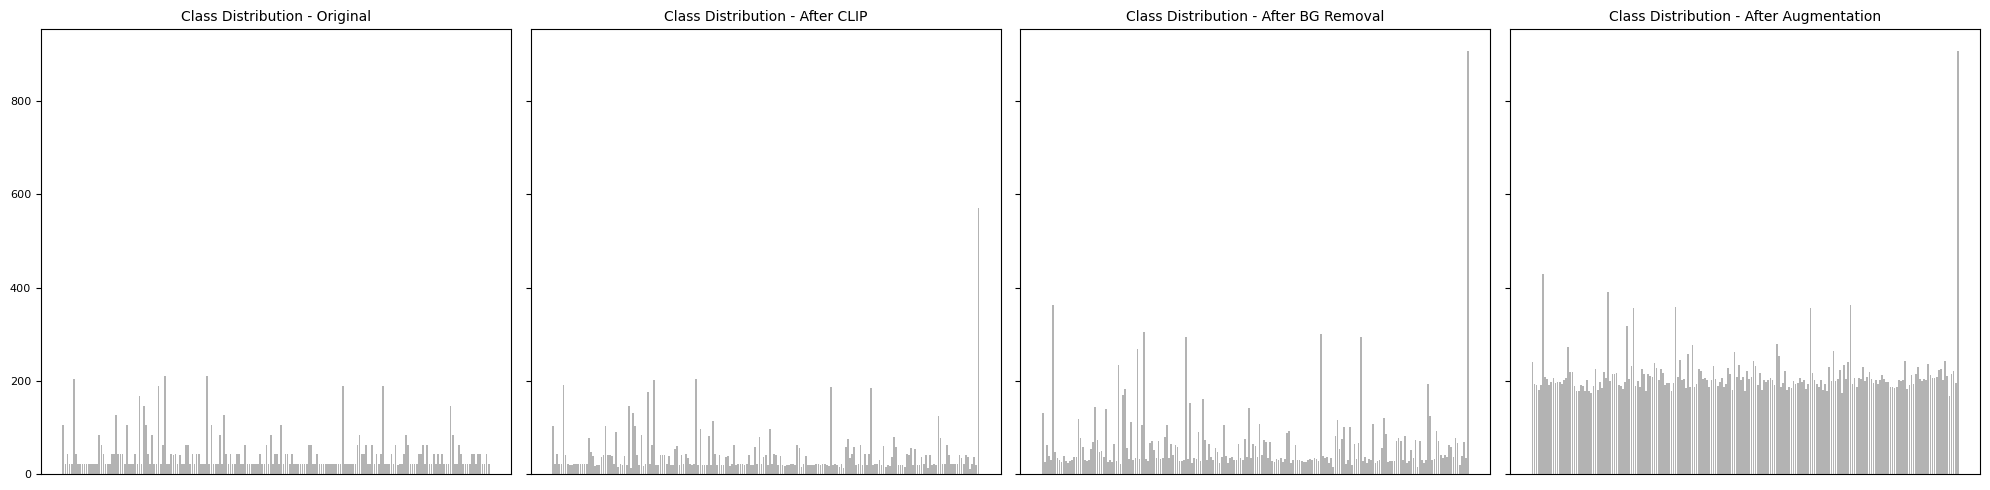

In [22]:
plot_class_evolution(train_df_preproc_clip_bg_aug)